In [8]:
import os
import pandas as pd

import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Predictive_Maintenance_FD001")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1778401818389, experiment_id='1', last_update_time=1778401818389, lifecycle_stage='active', name='Predictive_Maintenance_FD001', tags={}, trace_location=None, workspace='default'>

In [9]:
best_model = "runs:/a0eb60e7be04417fa652b08a12e372b9/random_forest_model"
model = mlflow.sklearn.load_model(best_model)

In [10]:
#Load processed dataset and separate into training and testing

DATA_DIR = os.path.join(r"D:\Upskill\Mini_Projects\intelligent-predictive-maintenance-system\CMAPSS_Data")

train_df = pd.read_csv(os.path.join(DATA_DIR, "processed", "train_features.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "processed", "test_features.csv"))

# Separating input from output
y_train = train_df['failure_risk']
y_test = test_df['failure_risk']

drop_columns = ['engine_id', 'cycle', 'RUL', 'failure_risk']
x_train = train_df.drop(columns=drop_columns)
x_test = test_df.drop(columns=drop_columns)

In [13]:
import json

for i in range(-1, -100, -10):    
    print(json.dumps(test_df.iloc[i].to_dict()))
    print(json.dumps(x_test.iloc[i].to_dict()))
    print()

{"engine_id": 100.0, "cycle": 198.0, "operational_setting_1": 0.0013, "operational_setting_2": 0.0003, "operational_setting_3": 100.0, "sensor_1": 518.67, "sensor_2": 642.95, "sensor_3": 1601.62, "sensor_4": 1424.99, "sensor_5": 14.62, "sensor_6": 21.61, "sensor_7": 552.48, "sensor_8": 2388.06, "sensor_9": 9155.03, "sensor_10": 1.3, "sensor_11": 47.8, "sensor_12": 521.07, "sensor_13": 2388.05, "sensor_14": 8214.64, "sensor_15": 8.4903, "sensor_16": 0.03, "sensor_17": 396.0, "sensor_18": 2388.0, "sensor_19": 100.0, "sensor_20": 38.7, "sensor_21": 23.1855, "RUL": 20.0, "failure_risk": 1.0, "sensor_1_lag1": 518.67, "sensor_1_lag2": 518.67, "sensor_1_mean5": 518.67, "sensor_1_std5": 0.0, "sensor_2_lag1": 643.26, "sensor_2_lag2": 643.44, "sensor_2_mean5": 643.222, "sensor_2_std5": 0.1755562587890501, "sensor_3_lag1": 1594.99, "sensor_3_lag2": 1593.15, "sensor_3_mean5": 1596.98, "sensor_3_std5": 3.461343669732828, "sensor_4_lag1": 1419.36, "sensor_4_lag2": 1406.82, "sensor_4_mean5": 1417.802

In [12]:
#Create SHAP explainer
import shap
explainer = shap.TreeExplainer(model=model)

In [16]:
#Compute SHAP values
sample = x_test.sample(500, random_state=42)
shap_values = explainer(sample)

In [18]:
print(shap_values.shape)

(500, 109, 2)


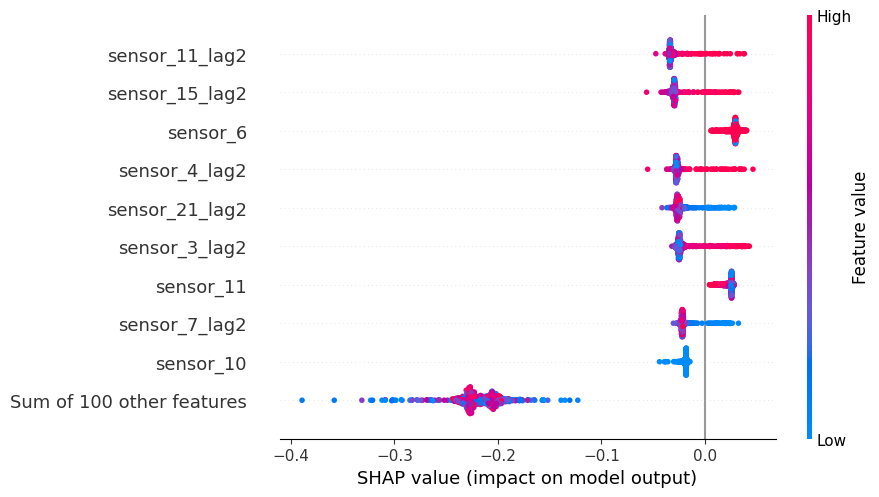

In [19]:
shap.plots.beeswarm(shap_values[:, :, 1])

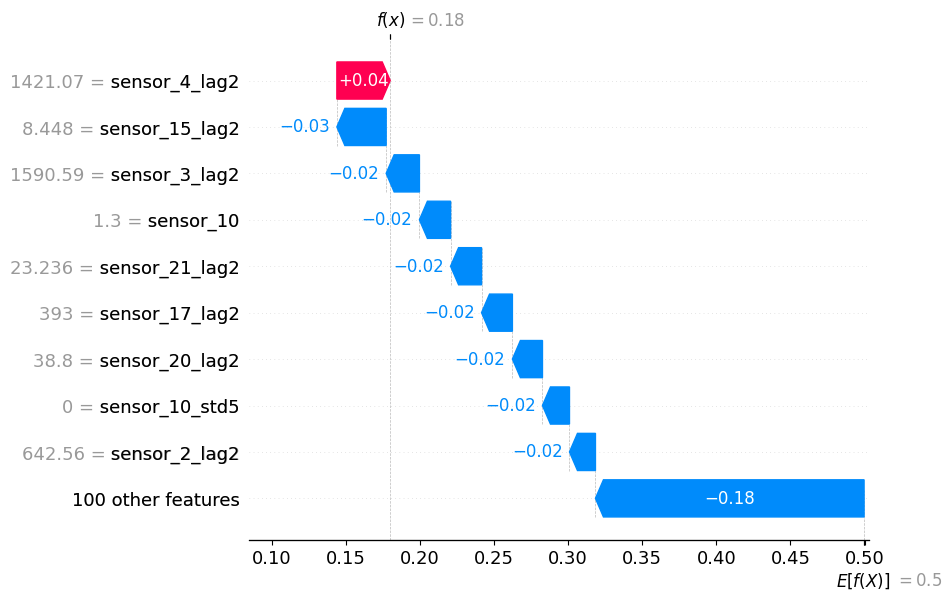

In [20]:
shap.plots.waterfall(shap_values[0, :, 1])

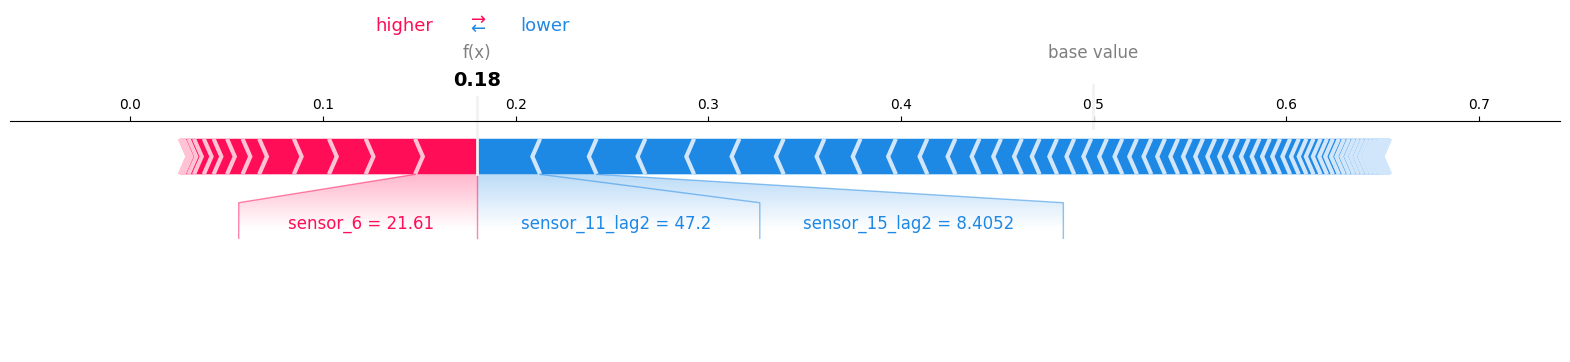

In [27]:
sample_row = x_test.iloc[[0]]

single_shap = explainer(sample_row)

shap.force_plot(
    explainer.expected_value[1],
    single_shap.values[0, :, 1],
    sample_row.iloc[0],
    matplotlib=True
)